# 1) About

This notebook performs an exploratory analysis of the AMLSim dataset to understand:

- dataset structure and schema
- dataset scale and composition
- relationships between tables
- data quality (missing values, duplicates)
- numerical and categorical distributions
- time coverage
- structural properties of the transaction network

The goal is to build a foundational understanding of the dataset before performing behavioral AML analysis. 

## Dataset

The dataset used in this analysis is generated using AMLSim, an open-source synthetic financial transaction simulator designed for research in anti-money laundering (AML) and financial crime detection.

AMLSim produces realistic transaction networks that simulate both legitimate financial activity and synthetic money laundering scenarios.


| Dataset             | Description                          |
| ------------------- | ------------------------------------ |
| `accounts.csv`      | Bank account information             |
| `transactions.csv`  | Transaction records between accounts |
| `alerts.csv`        | Suspicious activity alerts           |

**Note:** AMLSim TimeStamp is a simulation step. This project will assume that time stamp represents the day index. Start date is assumed to be *01-01-2020*.



## Findings

- No duplicates or nulls, indicating that dataset is consistent and suitable for further analysis.

- All clients are based in US & Individuals.

- Between client_id and account_id there is 1-1 mapping, following this convention -> client_id = c_{account_id}. Therefore account_id can be used as the primary key.

- A client can be only either fraudulent or non-fraudulent.

- Trx history from 2020-01-01 to 2020-07-18

- TrxId is the unique identifier

- One trx-id is either fraudulent or non-fraudulent

- All senders and receivers are within the client set

- Alerts are transaction-level (but my model will be client-level).

- One alert id can be associated with multiple transaction ids: 1:* relationship between AlertId and TransactionId

- All transactionids in the alert dataset is fradulent

- Max and min dates in Alerts dataset 2020-01-01 - 2020-07-18





# 2) Imports and Definitions

In [70]:
import pandas as pd
import numpy as np

from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option('display.expand_frame_repr', False)


In [132]:
data_path = Path("../data/raw")

df_acc = pd.read_csv(data_path/ "accounts.csv") 
df_trx = pd.read_csv(data_path/ "transactions.csv") 
df_alerts = pd.read_csv(data_path/ "alerts.csv") 


# Handling TimeStamps
start_date = pd.Timestamp("2020-01-01")
df_trx["date"] = start_date + pd.to_timedelta(df_trx["TIMESTAMP"], unit="D")
df_alerts["date"] = start_date + pd.to_timedelta(df_alerts["TIMESTAMP"], unit="D")


df_alerts["datetime"] = pd.to_datetime(df_alerts["date"])
df_trx["datetime"] = pd.to_datetime(df_trx["date"])

# Dataset Container for easier access

datasets = {
    "accounts": df_acc,
    "transactions": df_trx,
    "alerts": df_alerts,

}


# 3) Data Overview

## 3.a General Overview

> No duplicates or nulls, indicating that dataset is consistent and suitable for further analysis.

In [72]:
for name, df in datasets.items():
    
    print(f"Dataset: {name}")
    print("-" * 50)
    
    print("Shape:")
    print(df.shape)
    print()
    
    print("Info:")
    df.info()
    print()
    
    print("Head:")
    print(df.head())
    print()
    
    print("Null values:")
    print(df.isnull().sum())
    print()
    
    print("Duplicate rows:")
    print(df.duplicated().sum())
    print()
    
    print("=" * 70)
    print("\n")

   

Dataset: accounts
--------------------------------------------------
Shape:
(10000, 7)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      10000 non-null  int64  
 1   CUSTOMER_ID     10000 non-null  str    
 2   INIT_BALANCE    10000 non-null  float64
 3   COUNTRY         10000 non-null  str    
 4   ACCOUNT_TYPE    10000 non-null  str    
 5   IS_FRAUD        10000 non-null  bool   
 6   TX_BEHAVIOR_ID  10000 non-null  int64  
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 478.6 KB

Head:
   ACCOUNT_ID CUSTOMER_ID  INIT_BALANCE COUNTRY ACCOUNT_TYPE  IS_FRAUD  TX_BEHAVIOR_ID
0           0         C_0        184.44      US            I     False               1
1           1         C_1        175.80      US            I     False               1
2           2         C_2        142.06      US            I     Fal

## 3.b Deeper Look

### Accounts


#### Data Model:


- How many customers, how many accounts? (client id - account id -> is it one to many or one to many mapping?)

- Account types?

- Can one client have both fraud and nonfraud?


#### Findings:


- All clients are based in US & Individuals.

- Between client_id and account_id there is 1-1 mapping, following this convention -> client_id = c_{account_id}. Therefore account_id can be used as the primary key.

- A client can be only either fraudulent or non-fraudulent.

- Trx history spans from 2020-01-01 to 2020-07-18

- TrxId is the unique identifier

- One trx-id is either fraudulent or non-fraudulent

- All senders and receivers are within the client set

- Alerts are transaction-level (but my model will be client-level).



In [73]:
print("\n1. General Distribution:")


print(f"   Number of Distinct ClientIds: {df_acc['CUSTOMER_ID'].nunique()}")
print(f"   Number of Distinct AccountIds: {df_acc['ACCOUNT_ID'].nunique()}")
print(f"   Number of Distinct Countries: {df_acc['COUNTRY'].nunique()}, Countries:{df_acc['COUNTRY'].unique()}")
print(f"   Number of Distinct ACCOUNT_TYPEs: {df_acc['ACCOUNT_TYPE'].nunique()}, Types:{df_acc['ACCOUNT_TYPE'].unique()}")
print(f"   Number of Distinct TX_BEHAVIOR_IDs: {df_acc['TX_BEHAVIOR_ID'].nunique()}, TX_BEHAVIOR_IDs:{df_acc['TX_BEHAVIOR_ID'].unique()}")
print(f"   Number of Distinct IS_FRAUD: {df_acc['IS_FRAUD'].nunique()}, IS_FRAUD:{df_acc['IS_FRAUD'].unique()}")
# print("\n5. FRAUD DISTRIBUTION:"

print("\n2. ClientId - AccountId Mapping: ")

df_acc.groupby(['CUSTOMER_ID', 'ACCOUNT_ID']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(10)


print('Does all of client_ids == c_{account_ids}?')
(df_acc["CUSTOMER_ID"] == "C_" + df_acc["ACCOUNT_ID"].astype(str)).all()


print('\n3. Fraud Inspection: Can a client be both fraud and non-fraud?')

df_acc.groupby(
    ['CUSTOMER_ID', 'ACCOUNT_ID']
)['IS_FRAUD'].nunique().reset_index(name='UniqueValues').where(lambda x: x['UniqueValues'] > 1).query("UniqueValues > 1")



1. General Distribution:
   Number of Distinct ClientIds: 10000
   Number of Distinct AccountIds: 10000
   Number of Distinct Countries: 1, Countries:<StringArray>
['US']
Length: 1, dtype: str
   Number of Distinct ACCOUNT_TYPEs: 1, Types:<StringArray>
['I']
Length: 1, dtype: str
   Number of Distinct TX_BEHAVIOR_IDs: 5, TX_BEHAVIOR_IDs:[1 2 3 4 5]
   Number of Distinct IS_FRAUD: 2, IS_FRAUD:[False  True]

2. ClientId - AccountId Mapping: 
Does all of client_ids == c_{account_ids}?

3. Fraud Inspection: Can a client be both fraud and non-fraud?


,CUSTOMER_ID,ACCOUNT_ID,UniqueValues



### Transactions

#### Data Quality:

- Data types

- Null/ missing value inspection

- Formatting


#### Data Model:

- Is transactionid primary key?

- Can a transaction be both fradulent and non-fradulent? 

- Are all receivers and senders our clients?



#### Findings:

- Trx history from 2020-01-01 to 2020-07-18

- TrxId is the unique identifier

- One trx-id is either fraudulent or non-fraudulent

- All senders and receivers are within the client set

- Alerts are transaction-level (but my model will be client-level).

In [74]:
print('\n1. General Distribution:')


print(f"   Number of Distinct TransactionIds: {df_trx['TX_ID'].nunique()}")
print(f"   Number of Distinct ReceviverAccountIds: {df_trx['RECEIVER_ACCOUNT_ID'].nunique()}, Number of Distinct SenderAccountIds: {df_trx['SENDER_ACCOUNT_ID'].nunique()}")
print(f"   Number of Distinct TransactionTypes: {df_trx['TX_TYPE'].nunique()}, Types:{df_trx['TX_TYPE'].unique()}")
print(f"  Number of Distinct Fraud Status: {df_trx['IS_FRAUD'].nunique()}, Channels:{df_trx['IS_FRAUD'].unique()}")
print(f"  Number of Distinct AlertIds: {df_trx['ALERT_ID'].nunique()},  AlertIds:{sorted(df_trx['ALERT_ID'].unique())}")
print(f"  Number of Distinct TimeStamps: {df_trx['TIMESTAMP'].nunique()}, TimeStamps:{df_trx['TIMESTAMP'].unique()}")
print('\n Is TransactionId the Unique Key?:')
print(f"   Number of Distinct TransactionIds: {df_trx['TX_ID'].nunique()}, Total Rows: {len(df_trx)}")



print('\n2. Fraud Inspection')
print('\n Number of Fraud and Non-Fraud Transactions:')
print(df_trx['IS_FRAUD'].value_counts())


('print \n Can a transaction be both fraud and non-fraud?')
df_trx.groupby(
    ['TX_ID']
)['IS_FRAUD'].nunique().reset_index(name='UniqueValues').where(lambda x: x['UniqueValues'] > 1).query("UniqueValues > 1")


print('\n3. Senders/Receivers')
print(f"   Number of Distinct ReceviverAccountIds: {df_trx['RECEIVER_ACCOUNT_ID'].nunique()}, Number of Distinct SenderAccountIds: {df_trx['SENDER_ACCOUNT_ID'].nunique()}")



print(f"   Are all senders and receivers in the accounts dataset?")
sender_accounts = set(df_trx['SENDER_ACCOUNT_ID'].unique())
receiver_accounts = set(df_trx['RECEIVER_ACCOUNT_ID'].unique())
account_ids = set(df_acc['ACCOUNT_ID'].unique())

missing_senders = sender_accounts - account_ids
missing_receivers = receiver_accounts - account_ids

print(f"   Missing Sender Accounts: {missing_senders}")
print(f"   Missing Receiver Accounts: {missing_receivers}")


print(f"   Max and Min Transaction Dates: {df_trx['date'].min()}, {df_trx['date'].max()}")



1. General Distribution:
   Number of Distinct TransactionIds: 1323234
   Number of Distinct ReceviverAccountIds: 9926, Number of Distinct SenderAccountIds: 9999
   Number of Distinct TransactionTypes: 1, Types:<StringArray>
['TRANSFER']
Length: 1, dtype: str
  Number of Distinct Fraud Status: 2, Channels:[False  True]
  Number of Distinct AlertIds: 392,  AlertIds:[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44

### 


### Transactions

#### Data Quality:

- Data types

- Null/ missing value inspection

- Formatting


#### Data Model:




#### Findings:

- One alert id can be associated with multiple transaction ids: 1:* relationship between AlertId and TransactionId

- All transactionids in the alert dataset is fradulent

- Max and min dates in Alerts dataset 2020-01-01 - 2020-07-18

In [75]:
print('\n1. General Distribution:')


print(f"   Number of Distinct TransactionIds: {df_alerts['TX_ID'].nunique()} vs. number of rows: {len(df_alerts)}")
print(f"   Number of Distinct ALERT_IDs: {df_alerts['ALERT_ID'].nunique()} vs. number of rows: {len(df_alerts)}")

print(f" Can multiple transactions be associated with the same alert? {df_alerts['ALERT_ID'].duplicated().sum() > 0}")

print(f"   Number of Distinct AlertTypes: {df_alerts['ALERT_TYPE'].nunique()}, Types:{df_alerts['ALERT_TYPE'].unique()}")

print(f"   Alert Type Distribution:\n{df_alerts['ALERT_TYPE'].value_counts()}")

print(f"   How many of them is_fraud?: {df_alerts['IS_FRAUD'].value_counts()}")

print(f"   Are all alert transactions in the transactions dataset? {df_alerts['TX_ID'].isin(df_trx['TX_ID']).all()}")

print(f" max and min dates in alerts: {df_alerts['date'].min()} - {df_alerts['date'].max()}")



1. General Distribution:
   Number of Distinct TransactionIds: 1719 vs. number of rows: 1719
   Number of Distinct ALERT_IDs: 391 vs. number of rows: 1719
 Can multiple transactions be associated with the same alert? True
   Number of Distinct AlertTypes: 2, Types:<StringArray>
['fan_in', 'cycle']
Length: 2, dtype: str
   Alert Type Distribution:
ALERT_TYPE
cycle     936
fan_in    783
Name: count, dtype: int64
   How many of them is_fraud?: IS_FRAUD
True    1719
Name: count, dtype: int64
   Are all alert transactions in the transactions dataset? True
 max and min dates in alerts: 2020-01-01 00:00:00 - 2020-07-18 00:00:00


##### AlertId - Transactions 

What is the pattern in same AlertIds? 

- Seems like for fan_in alerts, transactions for the same receiver get the same AlertI -> Yes.

- Seems like for cycle alerts, transactions with the same transaction amount gets the same AlertId -> No.


In [76]:
df_alerts.sort_values("ALERT_ID").head(50)

# Does all fan_in alerts get the same alert_id for the same receiver id?

df_alerts[df_alerts["ALERT_TYPE"] == "fan_in"].groupby("ALERT_ID")["RECEIVER_ACCOUNT_ID"].nunique().reset_index(name='UniqueReceivers').query("UniqueReceivers > 1")


,ALERT_ID,UniqueReceivers


In [77]:
df_alerts[df_alerts["ALERT_TYPE"] == "cycle"].sort_values('ALERT_ID').head(50)

# Does all cycle alerts get the same alert_id if they have the same transaction amount? No, there are multiple alert_ids for the same transaction amount.

df_alerts[df_alerts["ALERT_TYPE"] == "cycle"].groupby('TX_AMOUNT')['ALERT_ID'].nunique().reset_index(name='UniqueAlertIds').query("UniqueAlertIds > 1")




,TX_AMOUNT,UniqueAlertIds
15,10.60,2
26,11.27,2
31,11.52,2
32,11.64,2
45,12.56,3
56,13.15,2
63,13.56,2
88,14.96,2
99,15.43,2
104,15.86,2


# 3) Distributions

## a. Transaction Amount

The distribution of transaction amounts is highly right-skewed, with the majority of transactions concentrated at relatively low values and a small number of transactions occurring at substantially higher amounts. To improve interpretability, the amounts were log-transformed using (log10(x + 1)) which compresses large values while preserving the relative differences across orders of magnitude.

The median transaction amount (P50) is approximately 157, indicating that half of all transactions occur below this value. The 90th percentile (P90) occurs at approximately 548, suggesting that most transactions remain within a relatively moderate range. However, the 99th percentile (P99) increases sharply to approximately 1.85 million, highlighting the presence of extremely large transactions that form the long tail of the distribution.

This heavy-tailed pattern is typical in financial transaction datasets, where a large volume of small transactions is accompanied by a relatively small number of high-value transfers. The logarithmic scaling enables visualization of these multiple orders of magnitude within a single distribution plot.

- max transaction amount:  21474836.47 min transaction amount:  0.0

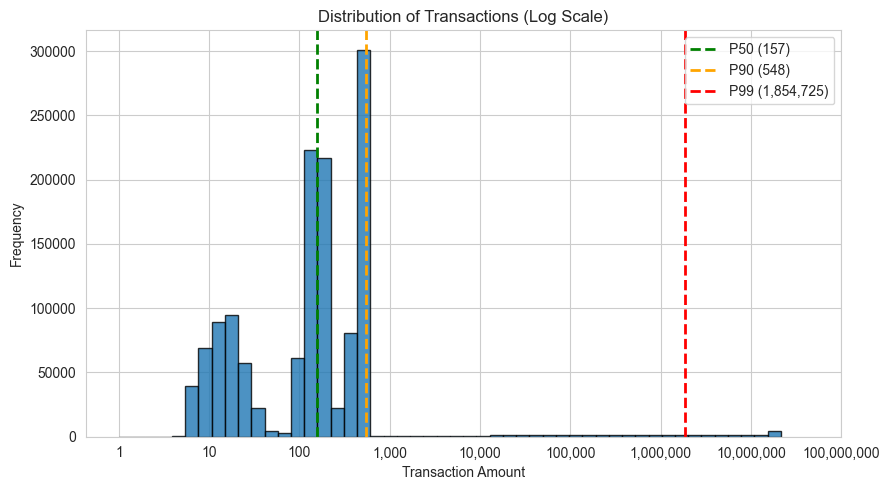

max transaction amount:  21474836.47 min transaction amount:  0.0


In [103]:
# Log transform - EXTREMELY SKEWED DISTRIBUTION - +1 ensures zero values are handled safely and improves visualization
log_amount = np.log10(df_trx["TX_AMOUNT"] + 1)

plt.figure(figsize=(9,5))
plt.hist(log_amount, bins=50, edgecolor="black", alpha=0.8)

max_log = int(np.ceil(log_amount.max()))
ticks = np.arange(0, max_log + 1)
tick_labels = [f"{int(10**t):,}" for t in ticks]

plt.xticks(ticks, tick_labels)

p50 = np.percentile(log_amount, 50)
p90 = np.percentile(log_amount, 90)
p99 = np.percentile(log_amount, 99)

# Convert percentiles back to real values
p50_real = 10**p50 - 1
p90_real = 10**p90 - 1
p99_real = 10**p99 - 1

# Plot percentile lines
plt.axvline(p50, color="green", linestyle="--", linewidth=2,
            label=f"P50 ({p50_real:,.0f})")

plt.axvline(p90, color="orange", linestyle="--", linewidth=2,
            label=f"P90 ({p90_real:,.0f})")

plt.axvline(p99, color="red", linestyle="--", linewidth=2,
            label=f"P99 ({p99_real:,.0f})")

# Labels
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transactions (Log Scale)")

plt.legend()
plt.tight_layout()

plt.show()

print('max transaction amount: ', df_trx["TX_AMOUNT"].max(), 'min transaction amount: ', df_trx["TX_AMOUNT"].min())


## Account Balances

Account balances are relatively evenly distributed between 100 and 600, with most accounts concentrated between 100 and 400. Compared to transaction amounts, balances show much less skewness, indicating a more controlled range of values.

- max balance:  599.6 min balance:  100.0

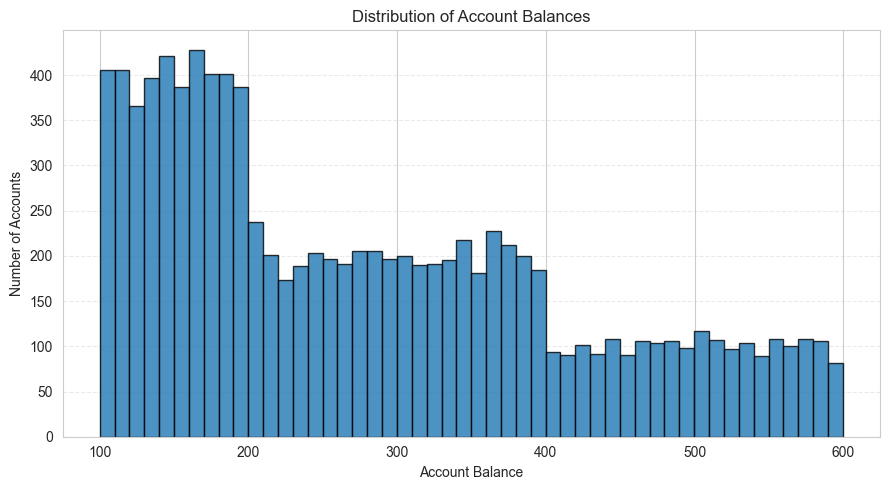

max balance:  599.6 min balance:  100.0


In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    df_acc["INIT_BALANCE"],
    bins=50,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Account Balance")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Account Balances")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


print('max balance: ', df_acc["INIT_BALANCE"].max(), 'min balance: ', df_acc["INIT_BALANCE"].min())


## Transaction Activity

- Transaction activity varies across accounts, with most accounts performing a relatively small number of transactions while a smaller subset of accounts exhibits higher activity levels. This uneven activity distribution is typical in transaction networks, where financial activity is often concentrated among a subset of participants.

- The maximum number of incoming transactions for an account is significantly higher than the maximum number of outgoing transactions. This indicates that certain accounts act as aggregation points, receiving funds from many other accounts. Such patterns are common in transaction networks where financial flows converge toward specific account (Hubs)

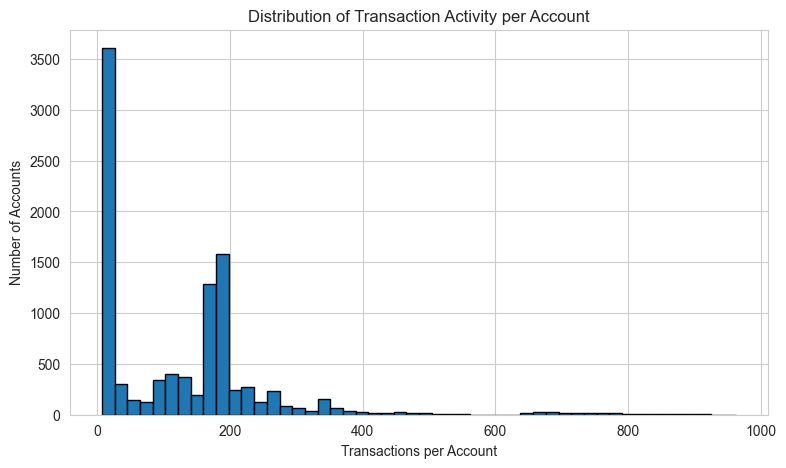

max transfers sent per account:  963 min transactions per account:  7


In [109]:
trx_per_sender = df_trx.groupby("SENDER_ACCOUNT_ID").size()

plt.figure(figsize=(9,5))
plt.hist(trx_per_sender, bins=50, edgecolor="black")

plt.xlabel("Transactions per Account")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Transaction Activity per Account")

plt.show()

print('max transfers sent per account: ', trx_per_sender.max(), 'min transactions per account: ', trx_per_sender.min())


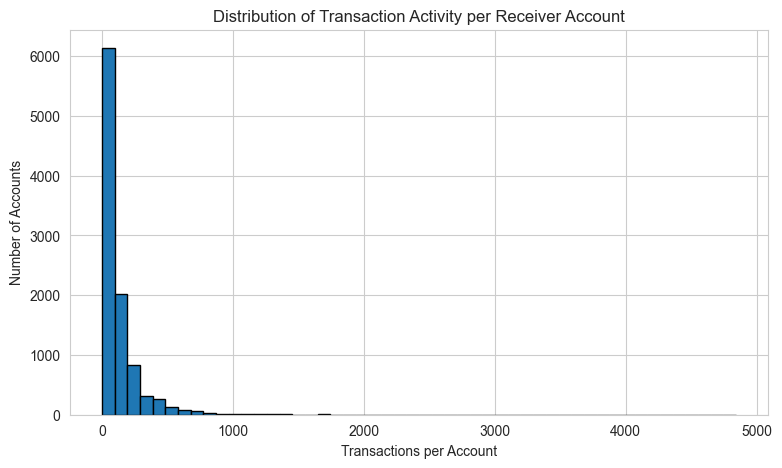

max transfers received per account:  4843 min transactions received per account:  1


In [110]:
trx_per_sender = df_trx.groupby("RECEIVER_ACCOUNT_ID").size()

plt.figure(figsize=(9,5))
plt.hist(trx_per_sender, bins=50, edgecolor="black")

plt.xlabel("Transactions per Account")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Transaction Activity per Receiver Account")

plt.show()

print('max transfers received per account: ', trx_per_sender.max(), 'min transactions received per account: ', trx_per_sender.min())


In [114]:
print(df_trx["RECEIVER_ACCOUNT_ID"].value_counts().head())

print(df_trx["SENDER_ACCOUNT_ID"].value_counts().head())


RECEIVER_ACCOUNT_ID
9982    4843
9993    3948
9971    3420
9983    2850
9998    2767
Name: count, dtype: int64
SENDER_ACCOUNT_ID
9799    963
9797    962
9785    922
9793    921
9790    921
Name: count, dtype: int64


### Aggregation Point - Hubs Inspection

The log–log scatter plot of incoming and outgoing transactions highlights heterogeneous participation across accounts. While most accounts exhibit relatively low transaction activity, a subset of accounts sends or receives substantially more transactions. Many accounts lie either above or below the diagonal reference line, indicating that some accounts act primarily as aggregation points while others serve more as distribution accounts within the transaction network.

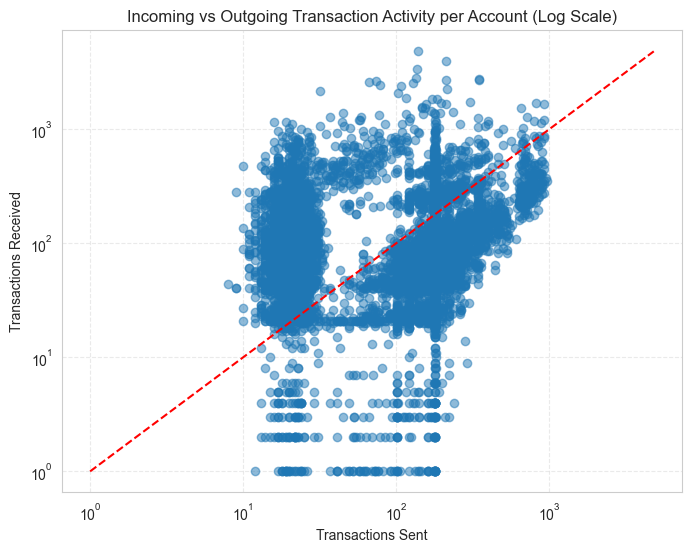

In [119]:
plt.figure(figsize=(8,6))

plt.scatter(
    activity["sent"] + 1,
    activity["received"] + 1,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Transactions Sent")
plt.ylabel("Transactions Received")
plt.title("Incoming vs Outgoing Transaction Activity per Account (Log Scale)")

plt.grid(True, linestyle="--", alpha=0.4)

max_val = max(activity["sent"].max(), activity["received"].max())

plt.plot([1, max_val], [1, max_val], color="red", linestyle="--")

plt.show()


## Alert Distibution 

A balanced distribution between Fan-in and Cycle Alert Types.

No clear trend is observed in alerts generated over time.

In [123]:
df_alerts.head()


,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,date
0,193,fan_in,True,82,6976,9739,TRANSFER,4.85,0,2020-01-01
1,377,cycle,True,949,5776,2570,TRANSFER,10.27,0,2020-01-01
2,189,fan_in,True,6280,9999,9530,TRANSFER,2.74,1,2020-01-02
3,377,cycle,True,7999,1089,7352,TRANSFER,10.27,1,2020-01-02
4,130,fan_in,True,12975,7025,9708,TRANSFER,3.53,2,2020-01-03


ALERT_TYPE
cycle     936
fan_in    783
Name: count, dtype: int64


<Axes: xlabel='datetime'>

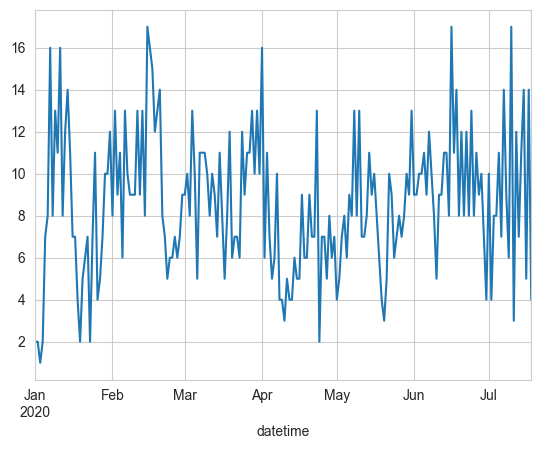

In [ ]:
# Alert type
print(df_alerts['ALERT_TYPE'].value_counts())

# Alerts Over Time
df_alerts.set_index("datetime").resample("D").size().plot()


## Transactions

- Transactions Over Time: No clear trend.

<Axes: xlabel='datetime'>

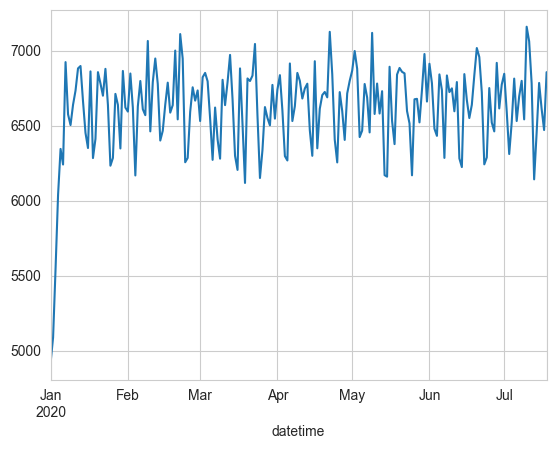

In [130]:
df_trx["datetime"] = pd.to_datetime(df_trx["date"])

df_trx.set_index("datetime").resample("D").size().plot()


## Network Size

In [131]:
nodes = set(df_trx["SENDER_ACCOUNT_ID"]).union(
    set(df_trx["RECEIVER_ACCOUNT_ID"])
)

edges = df_trx.shape[0]

print("Accounts:", len(nodes))
print("Transactions:", edges)


Accounts: 9999
Transactions: 1323234


# 4) Data Model - Relationships Between Tables

Identifier columns were examined to determine primary keys and relationships between tables. The ACCOUNT_ID column uniquely identifies accounts, while TX_ID uniquely identifies transactions. In the alerts table, TX_ID also uniquely identifies rows, indicating that each record corresponds to a transaction involved in an alert. The ALERT_ID column appears multiple times and therefore acts as a grouping identifier linking multiple transactions to the same alert event.

## Schema:

| Table | Key Column | Role | References |
|------|------|------|------|
| accounts | `ACCOUNT_ID` | Primary key | — |
| transactions | `TX_ID` | Primary key | — |
| transactions | `SENDER_ACCOUNT_ID` | Foreign key | accounts.ACCOUNT_ID |
| transactions | `RECEIVER_ACCOUNT_ID` | Foreign key | accounts.ACCOUNT_ID |
| alerts | `TX_ID` | Primary key | transactions.TX_ID |
| alerts | `ALERT_ID` | Group identifier | groups multiple transactions |

In [137]:
df_trx.info()


<class 'pandas.DataFrame'>
RangeIndex: 1323234 entries, 0 to 1323233
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   TX_ID                1323234 non-null  int64         
 1   SENDER_ACCOUNT_ID    1323234 non-null  int64         
 2   RECEIVER_ACCOUNT_ID  1323234 non-null  int64         
 3   TX_TYPE              1323234 non-null  str           
 4   TX_AMOUNT            1323234 non-null  float64       
 5   TIMESTAMP            1323234 non-null  int64         
 6   IS_FRAUD             1323234 non-null  bool          
 7   ALERT_ID             1323234 non-null  int64         
 8   date                 1323234 non-null  datetime64[us]
 9   datetime             1323234 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](2), float64(1), int64(5), str(1)
memory usage: 92.1 MB


In [139]:
def check_primary_key(df, col):
    print(f"Checking primary key candidate: {col}")
    print(f"Missing values: {df[col].isnull().sum()}")
    print(f"Duplicate values: {df[col].duplicated().sum()}")
    print(f"Unique values: {df[col].nunique()} / {len(df)}")
    print("-" * 50)

check_primary_key(df_acc, "ACCOUNT_ID")
check_primary_key(df_trx, "TX_ID")
check_primary_key(df_alerts, "ALERT_ID")
check_primary_key(df_alerts, "TX_ID")


Checking primary key candidate: ACCOUNT_ID
Missing values: 0
Duplicate values: 0
Unique values: 10000 / 10000
--------------------------------------------------
Checking primary key candidate: TX_ID
Missing values: 0
Duplicate values: 0
Unique values: 1323234 / 1323234
--------------------------------------------------
Checking primary key candidate: ALERT_ID
Missing values: 0
Duplicate values: 1328
Unique values: 391 / 1719
--------------------------------------------------
Checking primary key candidate: TX_ID
Missing values: 0
Duplicate values: 0
Unique values: 1719 / 1719
--------------------------------------------------


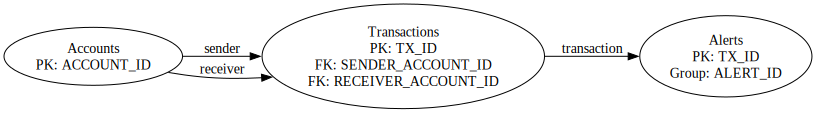

In [ ]:
from graphviz import Digraph

schema = Digraph(graph_attr={"rankdir": "LR"})

schema.node("accounts", "Accounts\nPK: ACCOUNT_ID")

schema.node(
    "transactions",
    "Transactions\nPK: TX_ID\nFK: SENDER_ACCOUNT_ID\nFK: RECEIVER_ACCOUNT_ID"
)

schema.node(
    "alerts",
    "Alerts\nPK: TX_ID\nGroup: ALERT_ID"
)

schema.edge("accounts", "transactions", label="sender")
schema.edge("accounts", "transactions", label="receiver")
schema.edge("transactions", "alerts", label="transaction")

schema
